# **Project Name**    - Ford Bike Sharing Project (EDA)



##### **Project Type**    - EDA
##### **Contribution** (Individual) - Ankit Kumar Sharma


# **Project Summary -**

This project focuses on analyzing individual bike rides made through the Ford GoBike sharing system in the San Francisco Bay Area. The primary objective of this analysis is to uncover user behavior patterns, determine key trends related to trip duration, and identify factors influencing ridership, ultimately providing actionable insights to enhance the efficiency and profitability of the bike-sharing system.

# **GitHub Link -**

[Ford Bike Sharing EDA Project](https://github.com/Ankit-604/Ford-Bike-Sharing/blob/main/Ford_Bike_Sharing_Project.ipynb)

# **Problem Statement**


The Ford GoBike bike-sharing system operates across the San Francisco Bay Area, providing convenient and eco-friendly transportation. However, to optimize operations, improve user experience, and expand its reach, the company needs a deeper understanding of user behavior, trip patterns, and system usage. Without these insights, it is difficult to make data-driven decisions regarding infrastructure expansion, targeted marketing, and service improvements. This project aims to analyze historical trip data to uncover key trends, user preferences, and operational inefficiencies.

#### **Define Your Business Objective?**

1. **Analyze Trip Durations -**

 * Determine how long the average trip lasts and identify any outliers.

 * Compare trip durations across different user types and demographics.

2. **Understand Temporal Patterns -**

 * Identify peak ride hours, days, and months.

 * Explore how seasonality impacts ride frequency and duration.

3. **Segment Users Based on Behavior -**

 * Compare the behavior of subscribers and casual customers.

 * Understand how gender and age influence riding habits.

4. **Identify High-Demand Stations -**

 * Locate the most popular start and end stations.

 * Provide recommendations for station expansion or bike redistribution.

5. **Improve User Experience -**

 * Identify user groups (e.g., casual riders or underrepresented demographics) for targeted engagement.

 * Suggest enhancements to service offerings based on usage data.

6. **Support Strategic Decisions -**

 * Provide data-driven recommendations to increase ridership, reduce operational bottlenecks, and enhance customer satisfaction.



# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
from google.colab import drive
warnings.filterwarnings('ignore')
import glob

### Dataset Loading

In [7]:
import pandas as pd
import glob
import os

# 1. Look for all CSV files inside the 'data' folder
path = 'data/*.csv'
csv_files = glob.glob(path)

# 2. Check if files were actually found
if not csv_files:
    print("Error: No CSV files found in the 'data/' folder. Please check your path.")
else:
    # 3. Load and combine all files
    print(f"Found {len(csv_files)} files. Loading and appending...")
    dfs = [pd.read_csv(file) for file in csv_files]
    fordbike_df = pd.concat(dfs, ignore_index=True)
    print(f"Successfully combined into a DataFrame with {len(fordbike_df)} rows.")

    # Display columns
    pd.set_option('display.max_columns', None)

Found 12 files. Loading and appending...
Successfully combined into a DataFrame with 1863721 rows.


### Dataset First View

In [8]:
# Dataset First Look
fordbike_df.head()

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,68529,2018-12-31 20:03:11.7350,2019-01-01 15:05:21.5580,217.0,27th St at MLK Jr Way,37.817015,-122.271761,217.0,27th St at MLK Jr Way,37.817015,-122.271761,3305,Customer,NaN,NaN,No
1,63587,2018-12-31 19:00:32.1210,2019-01-01 12:40:19.3660,NaN,NaN,37.400000,-121.940000,NaN,NaN,37.400000,-121.940000,4281,Customer,1995.0,Male,No
2,64169,2018-12-31 15:09:01.0820,2019-01-01 08:58:30.0910,NaN,NaN,37.400000,-121.940000,NaN,NaN,37.400000,-121.940000,4267,Customer,1988.0,Male,No
3,30550,2018-12-31 19:26:20.7750,2019-01-01 03:55:30.7930,13.0,Commercial St at Montgomery St,37.794231,-122.402923,19.0,Post St at Kearny St,37.788975,-122.403452,5422,Subscriber,1986.0,Male,Yes
4,2150,2018-12-31 23:59:12.0970,2019-01-01 00:35:02.1530,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,368.0,Myrtle St at Polk St,37.785434,-122.419622,4820,Customer,NaN,NaN,No


### Dataset Rows & Columns count

In [9]:
# Dataset Rows & Columns count
print('Number of Rows =',fordbike_df.shape[0])
print('Number of Columns =',fordbike_df.shape[1])

Number of Rows = 1863721
Number of Columns = 16


### Dataset Information

In [10]:
# Dataset Info
fordbike_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1863721 entries, 0 to 1863720
Data columns (total 16 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   duration_sec             int64  
 1   start_time               object 
 2   end_time                 object 
 3   start_station_id         float64
 4   start_station_name       object 
 5   start_station_latitude   float64
 6   start_station_longitude  float64
 7   end_station_id           float64
 8   end_station_name         object 
 9   end_station_latitude     float64
 10  end_station_longitude    float64
 11  bike_id                  int64  
 12  user_type                object 
 13  member_birth_year        float64
 14  member_gender            object 
 15  bike_share_for_all_trip  object 
dtypes: float64(7), int64(2), object(7)
memory usage: 227.5+ MB


#### Duplicate Values

In [11]:
# Dataset Duplicate Value Count
print('Number of duplicates in dataset =',fordbike_df.duplicated().sum())

Number of duplicates in dataset = 0


#### Missing Values/Null Values

In [12]:
# Missing Values/Null Values Count
print('Number of missing values in dataset =',fordbike_df.isnull().sum().sum())

Number of missing values in dataset = 268169


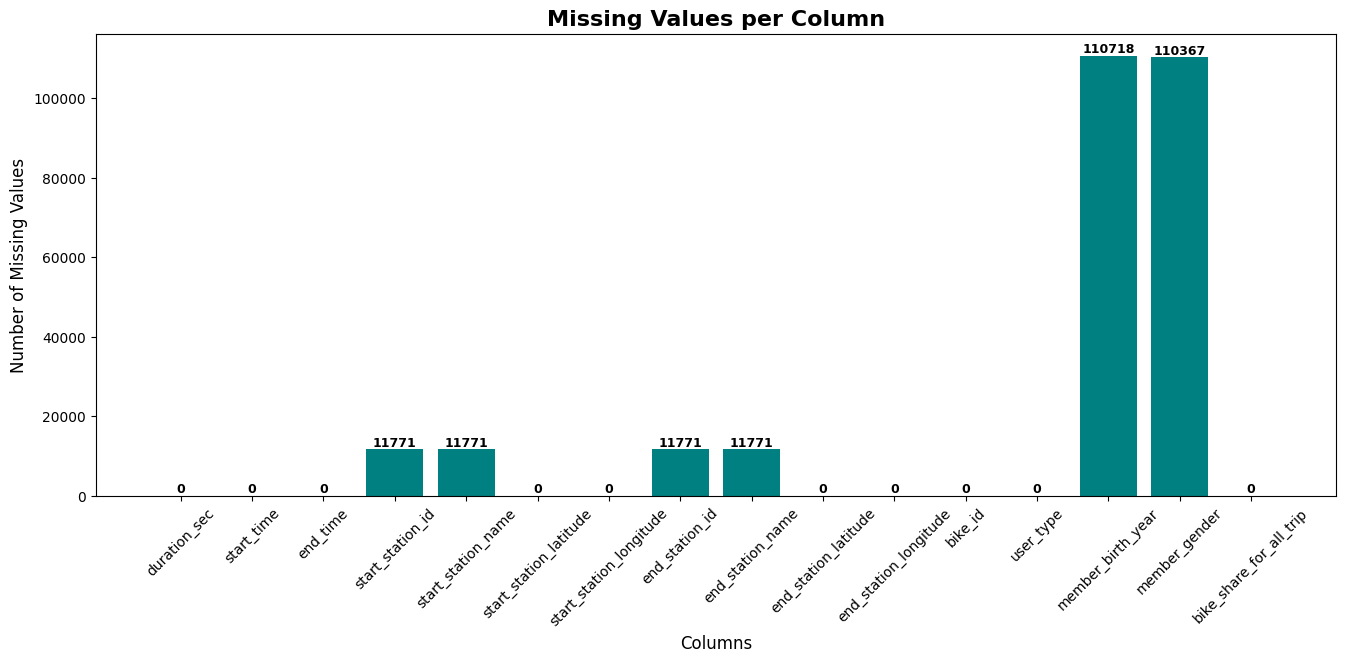

In [13]:
# Visualizing the missing values
# Calculating the number of missing values per column
missing_values = fordbike_df.isnull().sum()

# Plotting the missing values
fig, ax = plt.subplots(figsize=(16, 6))
bars = ax.bar(missing_values.index, missing_values.values, color='teal')

# Adding data labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval, f'{yval}',
            ha='center', va='bottom', fontsize=9, fontweight='bold', color='black')

# Adding labels and title
plt.title('Missing Values per Column', fontsize=16, fontweight='bold')
plt.xlabel('Columns', fontsize=12)
plt.ylabel('Number of Missing Values', fontsize=12)

# Rotating x-axis labels for better readability
plt.xticks(rotation=45)

# Display the plot
plt.show()

### What did you know about your dataset?

Based on the initial data exploration, here's what I know about your dataset:

*   **Size:** The dataset contains `1,863,721` rows and `16` columns.
*   **Data Types:** The columns include numerical types (`int64`, `float64`) and categorical/string types (`object`).
*   **Duplicate Values:** There are `0` duplicate rows in the dataset.
*   **Missing Values:** Several columns have missing values, notably:
    *   `start_station_id`, `start_station_name`, `end_station_id`, `end_station_name` each have `11,771` missing values.
    *   `member_birth_year` has `110,718` missing values.
    *   `member_gender` has `110,367` missing values.

These missing values will need to be addressed during data wrangling and cleaning.

### Insights from 'Missing Values per Column' Graph:

*   The columns related to **station information** (`start_station_id`, `start_station_name`, `end_station_id`, `end_station_name`) show an identical number of missing values (11,771). This suggests that if a station ID is missing, its corresponding name is also missing, and vice-versa, likely indicating a systemic issue when recording station details.
*   **Demographic information** (`member_birth_year` and `member_gender`) has the highest number of missing values, with `member_birth_year` having the most (110,718) and `member_gender` being very close (110,367). This strong correlation in missingness suggests that these two pieces of information are often not provided together, possibly due to user privacy preferences or optional fields during registration.
*   A significant portion of the columns, including `duration_sec`, `start_time`, `end_time`, `latitude/longitude` for both start and end stations, `bike_id`, `user_type`, and `bike_share_for_all_trip`, are **complete with no missing values**. This is positive for features derived from these columns.

## ***2. Understanding Your Variables***

In [14]:
# Dataset Columns
fordbike_df.columns

Index(['duration_sec', 'start_time', 'end_time', 'start_station_id',
       'start_station_name', 'start_station_latitude',
       'start_station_longitude', 'end_station_id', 'end_station_name',
       'end_station_latitude', 'end_station_longitude', 'bike_id', 'user_type',
       'member_birth_year', 'member_gender', 'bike_share_for_all_trip'],
      dtype='object')

In [15]:
# Dataset Describe
fordbike_df.describe()

,duration_sec,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bike_id,member_birth_year
count,1.863721e+06,1.851950e+06,1.863721e+06,1.863721e+06,1.851950e+06,1.863721e+06,1.863721e+06,1.863721e+06,1.753003e+06
mean,8.573026e+02,1.196744e+02,3.776678e+01,-1.223492e+02,1.181730e+02,3.776690e+01,-1.223487e+02,2.296851e+03,1.983088e+03
std,2.370379e+03,1.003976e+02,1.057689e-01,1.654634e-01,1.004403e+02,1.056483e-01,1.650597e-01,1.287733e+03,1.044289e+01
min,6.100000e+01,3.000000e+00,3.726331e+01,-1.224737e+02,3.000000e+00,3.726331e+01,-1.224737e+02,1.100000e+01,1.881000e+03
25%,3.500000e+02,3.300000e+01,3.777106e+01,-1.224114e+02,3.000000e+01,3.777106e+01,-1.224094e+02,1.225000e+03,1.978000e+03
50%,5.560000e+02,8.900000e+01,3.778107e+01,-1.223974e+02,8.800000e+01,3.778127e+01,-1.223971e+02,2.338000e+03,1.985000e+03
75%,8.720000e+02,1.860000e+02,3.779625e+01,-1.222865e+02,1.830000e+02,3.779728e+01,-1.222894e+02,3.333000e+03,1.991000e+03
max,8.636600e+04,3.810000e+02,4.551000e+01,-7.357000e+01,3.810000e+02,4.551000e+01,-7.357000e+01,6.234000e+03,2.000000e+03


### Variables Description

1. **duration_sec -** 	Duration of the trip in seconds

2. **start_time -** 	Date and time when the trip started
3. **end_time -**	Date and time when the trip ended
4. **start_station_id -**	Unique ID of the starting station
5. **start_station_name -**	Name of the starting station
6. **start_station_latitude -**	Latitude of the starting station
7. **start_station_longitude -**	Longitude of the starting station
8. **end_station_id -**	Unique ID of the ending station
9. **end_station_name -**	Name of the ending station
10. **end_station_latitude -**	Latitude of the ending station
11. **end_station_longitude -**	Longitude of the ending station
12. **bike_id -**	Unique identifier for the bike used
13. **user_type -**	Type of user Subscriber (member) or Customer (casual)
14. **member_birth_year** -	Birth year of the user
15. **member_gender -**	Gender of the user (Male, Female, or Other)
16. **bike_share_for_all_trip -**	Indicates whether the trip was part of the Bike Share for All program (Yes/No)

### Check Unique Values for each variable.

In [16]:
# Check Unique Values for each variable.
print('Unique Values in dataset:\n')
print(fordbike_df.nunique())

Unique Values in dataset:

duration_sec                 16709
start_time                 1863584
end_time                   1863610
start_station_id               331
start_station_name             348
start_station_latitude         369
start_station_longitude        370
end_station_id                 331
end_station_name               348
end_station_latitude           370
end_station_longitude          371
bike_id                       5054
user_type                        2
member_birth_year               86
member_gender                    3
bike_share_for_all_trip          2
dtype: int64


## 3. ***Data Wrangling***

### Data Wrangling Code

In [17]:
# Write your code to make your dataset analysis ready.

# Create copy of the dataset
df = fordbike_df.copy()

# 1. Convert start_time and end_time to datetime
df['start_time'] = pd.to_datetime(df['start_time'])
df['end_time'] = pd.to_datetime(df['end_time'])

In [18]:
# 2. Create new columns for date, time, and duration in minutes
df['start_date'] = df['start_time'].dt.date
df['start_hour'] = df['start_time'].dt.hour
df['start_day'] = df['start_time'].dt.day_name()
df['start_month'] = df['start_time'].dt.month_name()
df['duration_min'] = df['duration_sec'] / 60  # Convert seconds to minutes


In [19]:
# 3. Handle missing values

# Dropping rows with missing member_birth_year and member_gender
df = df.dropna(subset=['member_birth_year', 'member_gender'])

# Checking missing values after handling
print("\nMissing values after handling:")
print(df.isnull().sum())


Missing values after handling:
duration_sec                   0
start_time                     0
end_time                       0
start_station_id           11447
start_station_name         11447
start_station_latitude         0
start_station_longitude        0
end_station_id             11447
end_station_name           11447
end_station_latitude           0
end_station_longitude          0
bike_id                        0
user_type                      0
member_birth_year              0
member_gender                  0
bike_share_for_all_trip        0
start_date                     0
start_hour                     0
start_day                      0
start_month                    0
duration_min                   0
dtype: int64


In [20]:
# 4. Create age column from birth year
df['age'] = 2025 - df['member_birth_year']

In [21]:
# 5. Remove outliers in trip duration
# This helps to focus analysis on realistic trip lengths
duration_cap = df['duration_min'].quantile(0.99)
df = df[df['duration_min'] <= duration_cap]

In [22]:
# 6. Converting birth year and age to int
df['member_birth_year'] = df['member_birth_year'].astype(int)
df['age'] = df['age'].astype(int)

In [23]:
# 7. Drop irrelevant columns
df.drop(['bike_id', 'start_station_id', 'end_station_id'], axis=1, inplace=True)

In [24]:
# Dataset shape after cleaning
print('Number of Rows =',df.shape[0])
print('Number of Columns =',df.shape[1])

Number of Rows = 1735474
Number of Columns = 19


In [25]:
# View final dataset
df.head()

,duration_sec,start_time,end_time,start_station_name,start_station_latitude,start_station_longitude,end_station_name,end_station_latitude,end_station_longitude,user_type,member_birth_year,member_gender,bike_share_for_all_trip,start_date,start_hour,start_day,start_month,duration_min,age
5,2149,2018-12-31 23:59:11.882,2019-01-01 00:35:01.685,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,Myrtle St at Polk St,37.785434,-122.419622,Subscriber,1982,Male,Yes,2018-12-31,23,Monday,December,35.816667,43
6,2502,2018-12-31 23:46:24.943,2019-01-01 00:28:07.356,San Francisco Caltrain Station 2 (Townsend St...,37.776639,-122.395526,Civic Center/UN Plaza BART Station (Market St ...,37.781074,-122.411738,Customer,1973,Male,No,2018-12-31,23,Monday,December,41.700000,52
8,2170,2018-12-31 23:47:19.210,2019-01-01 00:23:30.130,The Embarcadero at Sansome St,37.804770,-122.403234,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,Customer,1999,Female,No,2018-12-31,23,Monday,December,36.166667,26
9,3645,2018-12-31 23:22:41.286,2019-01-01 00:23:27.268,The Embarcadero at Sansome St,37.804770,-122.403234,The Embarcadero at Vallejo St,37.799953,-122.398525,Customer,1999,Male,No,2018-12-31,23,Monday,December,60.750000,26
10,2182,2018-12-31 23:47:02.185,2019-01-01 00:23:24.495,The Embarcadero at Sansome St,37.804770,-122.403234,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,Customer,1999,Female,No,2018-12-31,23,Monday,December,36.366667,26


### What all manipulations have you done and insights you found?

### **Manipulations-**
1. **Datetime Conversions:**
 * `start_time` and `end_time` columns were converted to proper datetime formats. This allowed easy extraction of time-based features.
2. **Feature Engineering:**
 * Trip Duration (`duration_min`) was created by converting `duration_sec` to minutes.
 * Extracted new columns from `start_time`: `start_hour` (hour of the day), `start_day` (day of week), and `start_month` (month name).
 * Calculated rider `age` (2025 - `member_birth_year`).
3. **Data Type Conversion:** Numerical fields like `member_birth_year` and `age` were converted to integer data types for consistency.
4. **Filtering Outliers:** Trips with extremely high durations (specifically, above the 99th percentile of `duration_min`) were removed to ensure accuracy and focus analysis on realistic trip lengths.
5. **Handling Missing Data:** Rows with missing values in `member_birth_year` and `member_gender` were removed to maintain data quality.
6. **Dropping Irrelevant Columns:** Columns such as `bike_id`, `start_station_id`, and `end_station_id` were dropped as they were not directly needed for the planned analysis.

---
### **Insights-**
1. **Data Quality Improvements:** Identified and addressed issues with missing demographic data (`member_gender`, `member_birth_year`) and extreme outliers in trip durations, leading to a cleaner and more reliable dataset for analysis.
2. **Enhanced Feature Set:** Created new time-based features (`start_hour`, `start_day`, `start_month`) and an `age` column, enabling a richer analysis of user behavior patterns related to time and demographics.
3. **Focus on Relevant Data:** By removing irrelevant identifier columns and filtering outliers, the dataset is now streamlined for key analytical objectives concerning trip duration, user types, and station usage.
4. **Initial Understanding of Usage:** The conversion of duration to minutes provides a more intuitive scale for understanding trip lengths, while the creation of age allows for demographic segmentation.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

In [28]:
# Setting visualization style
plt.style.use('fivethirtyeight')

####**Univariate Analysis**

#### Chart - 1 - Distribution of Trip Duration (in minutes)

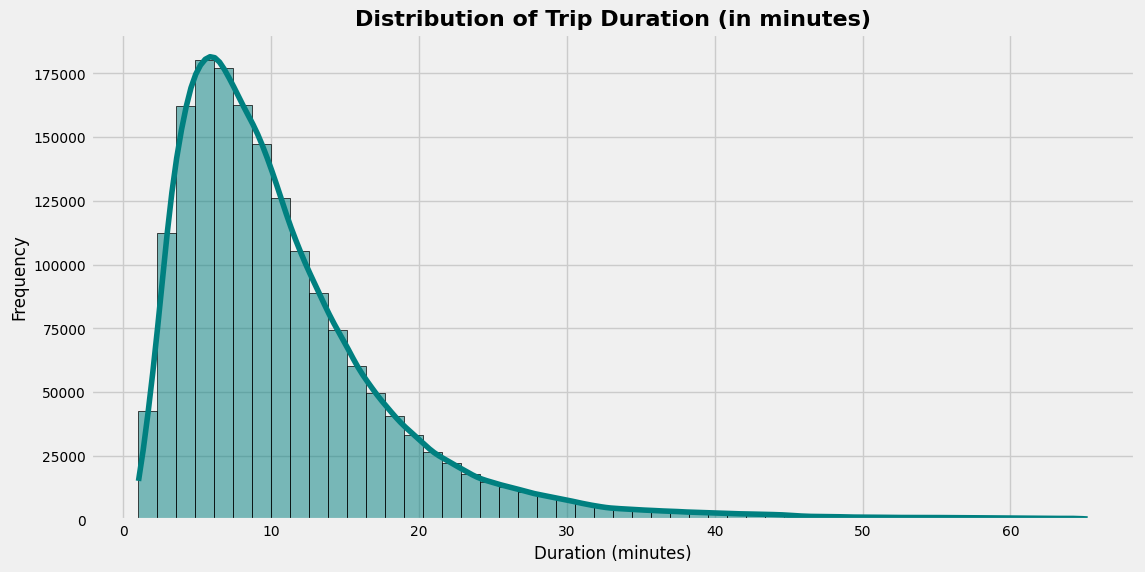

In [29]:
# Chart - 1 visualization code
# Histogram for trip duration
# Set figure size
plt.figure(figsize=(12, 6))
# Create histogram
sns.histplot(df['duration_min'], bins=50, color='teal', edgecolor='black', kde = True)
# Add labels and title
plt.title('Distribution of Trip Duration (in minutes)',fontsize = 16, fontweight='bold')
plt.xlabel('Duration (minutes)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
# Set font size for x & y axis value
plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)
# Show Plot
plt.show()

##### 1. Why did you pick the specific chart?

A histogram clearly shows how trip durations are distributed, helping identify common and extreme values.

##### 2. What is/are the insight(s) found from the chart?

1. **Right-Skewed Distribution:** The chart demonstrates a heavily right-skewed distribution of trip durations, meaning most trips are very short, while a decreasing number of trips last longer.

2. **Peak Utilization Window:** The peak of the distribution occurs between 5 to 10 minutes, where the frequency of trips is at its highest (reaching over 175,000 trips in the peak bins).

3. **Sharp Drop-off:** Trip frequency falls off dramatically after 15 to 20 minutes, indicating that the service is overwhelmingly used for short, rapid, point-to-point journeys.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact -**

* Short trip durations translate to rapid bike turnover, allowing the same inventory to be reused multiple times per day.

*   This high utilization helps operations accurately schedule morning and evening rebalancing at transit nodes before stations empty out.


**Strategic Consideration -**

*   The sharp drop-off after 20 minutes indicates that the system is heavily underutilized for leisure, weekend exploring, or tourist rides.

*  This represents an uncaptured revenue stream, meaning the business must rely on commuter traffic and should implement off-peak or weekend leisure pricing models to diversify.



#### Chart - 2 - User Types Distribution

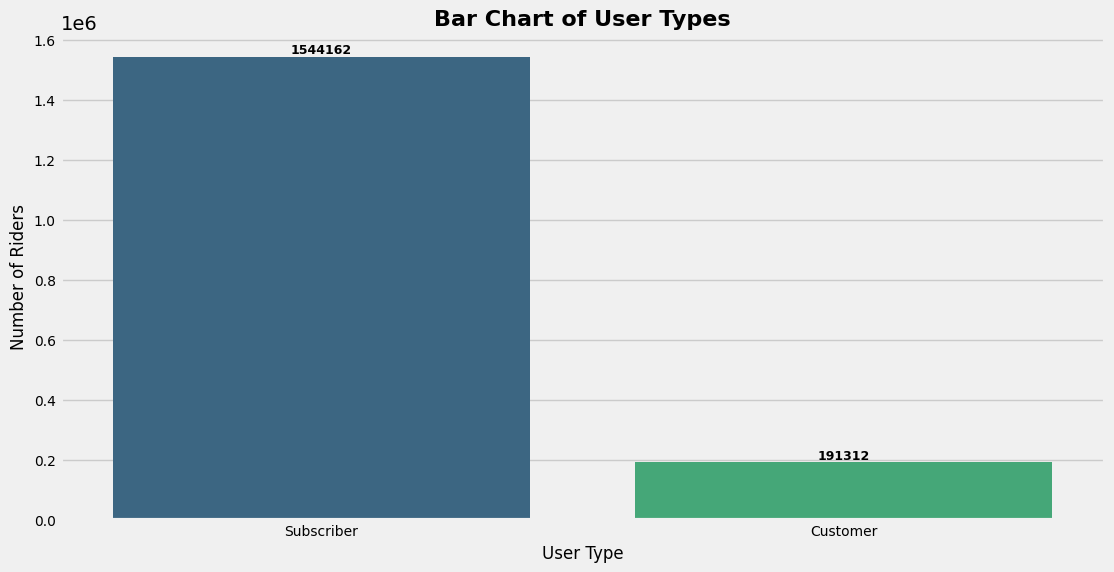

In [30]:
# Chart - 2 visualization code
# User Type Distribution
# Set figure size
plt.figure(figsize=(12, 6))
# Counting user types
user_type_counts = df['user_type'].value_counts()
# Create bar plot
sns.barplot(x=user_type_counts.index, y=user_type_counts.values, palette='viridis')
# Add data labels
for i, v in enumerate(user_type_counts.values):
    plt.text(i, v, str(v), ha='center', va='bottom', fontsize=9, fontweight='bold', color='black')
# Add labels and title
plt.title('Bar Chart of User Types', fontsize=16, fontweight='bold')
# Set font size for x & y axis value
plt.xlabel('User Type', fontsize=12)
plt.ylabel('Number of Riders', fontsize=12)
# Set font size for x & y axis value
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
# Show plot
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is ideal to compare categorical counts such as Subscriber vs Customer.

##### 2. What is/are the insight(s) found from the chart?

Majority are Subscribers, indicating high user retention and loyalty.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact -**


*   Having an ecosystem heavily anchored by subscribers gives highly predictable, recurring revenue.
*   It also proves strong long-term user retention, meaning marketing can spend less on constant win-back campaigns and focus more on fine-tuning daily operational consistency.



**Strategic Consideration -**


*   The small casual footprint suggests the system isn't effectively capturing single-use tourist or recreational weekend riders.
*   To unlock fresh revenue streams without hurting commuter flow, We can  introduce highly visible weekend tourist passes or special "off-peak" family tiers



#### Chart - 3 - Member Gender Distribution

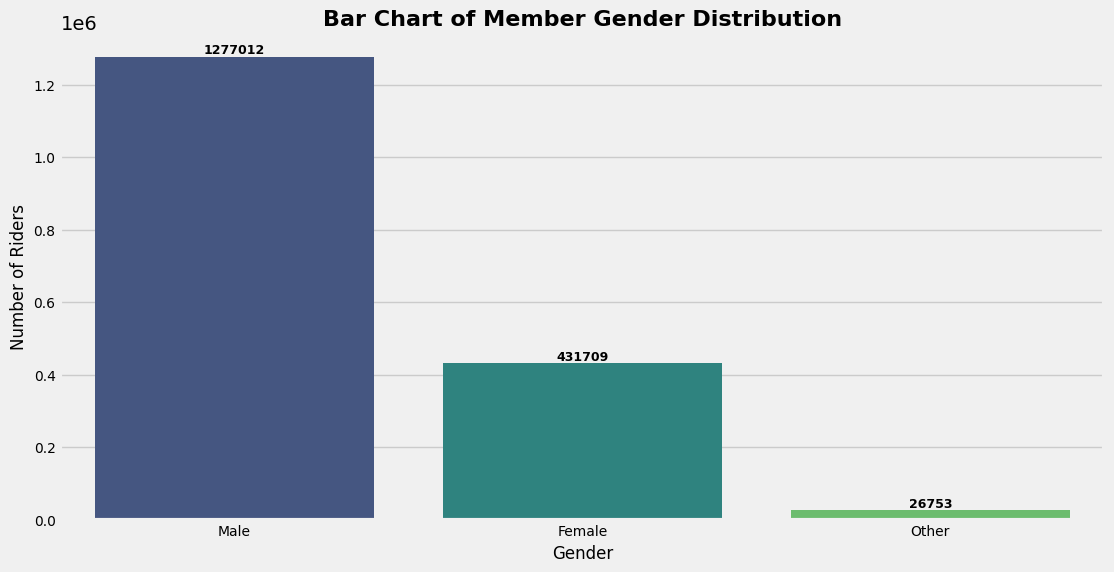

In [31]:
# Chart - 3 visualization code
# Member Gender Distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=df['member_gender'].value_counts().index, y=df['member_gender'].value_counts().values, palette='viridis')
for i, v in enumerate(df['member_gender'].value_counts().values):
    plt.text(i, v, str(v), ha='center', va='bottom', fontsize=9, fontweight='bold', color='black')
plt.title('Bar Chart of Member Gender Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Number of Riders', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

##### 1. Why did you pick the specific chart?

A bar plot is ideal as it helps to identify gender participation using a simple and clear comparison.

##### 2. What is/are the insight(s) found from the chart?

Males dominate ridership, with females underrepresented.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact -**


*   The massive volume of male riders demonstrates that the platform has successfully established strong product-market fit and reliable retention within this core segment.
*   This provides a highly stable revenue baseline, allowing the operations team to scale infrastructure and predict high-volume demand patterns with absolute confidence.



**Strategic Consideration -**


*   The severe gender gap highlights that the system is currently underutilized by female riders, suggesting possible barriers such as safety, station locations, or inadequate bike-sharing infrastructure.
*   This represents an incredible, untapped expansion opportunity; introducing female-focused marketing, community outreach, and safety features can rapidly capture this massive market segment.



#### Chart - 4 - Member Age Distribution

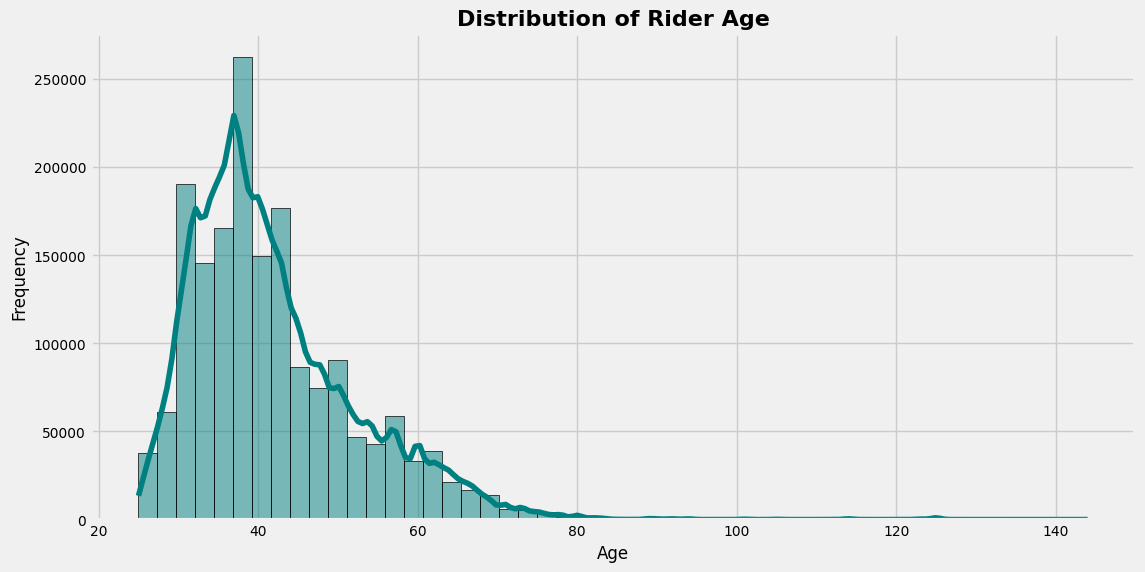

In [32]:
# Chart - 4 visualization code
# Member Age Distribution
# Create histogram
plt.figure(figsize=(12, 6))
sns.histplot(df['age'], bins=50, color='teal', edgecolor='black', kde = True)
# Add labels and title
plt.title('Distribution of Rider Age',fontsize = 16, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
# Setting font size for xticks and yticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
# Show Plot
plt.show()

##### 1. Why did you pick the specific chart?

Histograms show spread and concentration of rider age.

##### 2. What is/are the insight(s) found from the chart?

Most riders are between 25-40 years old, suggesting a young working demographic.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact -**


*   The strong clustering around ages 25–40 proves an exceptional product-market fit among the urban commuter and tech-savvy young professional workforce.
*   This clear audience profile allows the business to set up highly focused corporate B2B marketing partnerships, office-hub discount programs, and app integrations where workplace density is highest.



**Strategic Consideration -**


*   The steep decline in ridership among users over 50 indicates that older demographics find bike-sharing less accessible, possibly due to a lack of e-bikes, physical comfort issues, or minimal marketing outreach.
*   To unlock alternative revenue growth, the business should consider introducing step-through or electric-assist bike variations and tailored community pricing tiers to capture older suburban or off-peak riders.



#### Chart - 5 - Start Hour Distribution

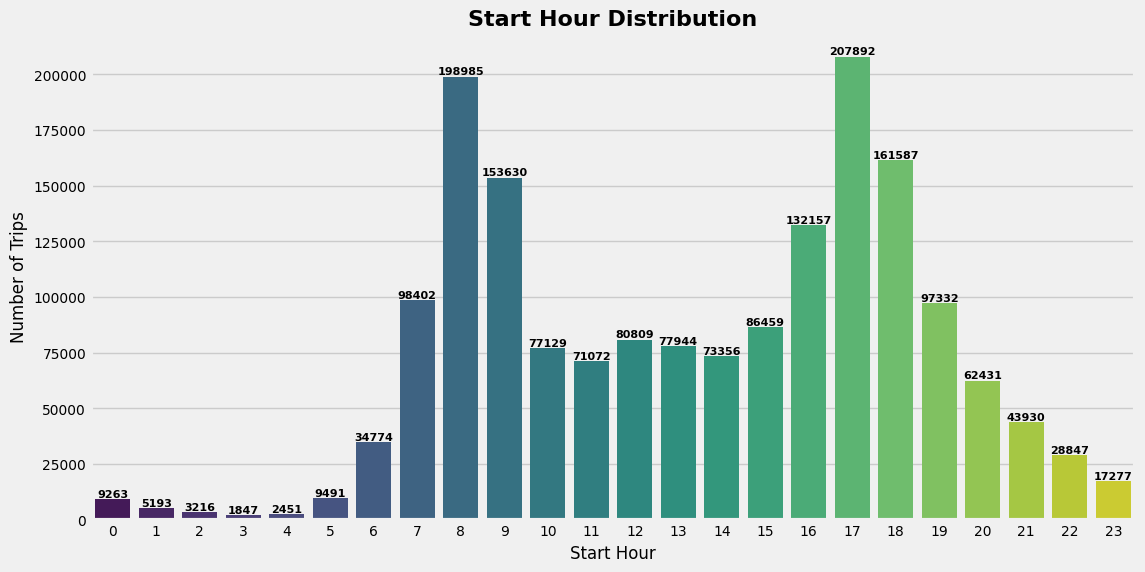

In [33]:
# Chart - 5 visualization code
# Start Hour Distribution
hourly = df['start_hour'].value_counts().sort_index()
# Create bar chart
plt.figure(figsize=(12, 6))
sns.barplot(x=hourly.index, y=hourly.values, palette='viridis')
# Add data labels
for i, v in enumerate(hourly.values):
    plt.text(i, v, str(v), ha='center', va='bottom', fontsize=8, fontweight='bold', color='black')
# Add title and labels
plt.title('Start Hour Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Start Hour', fontsize=12)
plt.ylabel('Number of Trips', fontsize=12)
# Setting font size for xticks and yticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
# Show Plot
plt.show()



##### 1. Why did you pick the specific chart?

Shows peak demand hours and usage patterns.

##### 2. What is/are the insight(s) found from the chart?

Peak usage occurs during 8 AM and 5-6 PM, confirming commute-driven behavior.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact -**


*   Highly predictable rush hours allow operations to schedule bike rebalancing and maintenance during low-volume midday and late-night slots without interrupting core revenue.
*   Clear commuter patterns make the service highly attractive for B2B corporate partnerships and employer-subsidized transit passes centered around office districts.



**Strategic Consideration -**


*   Low off-peak and night volumes indicate the system is underutilized by leisure riders, shoppers, and tourists outside of standard work hours.
*   To fill these slow slots, the business should introduce targeted mid-day lunch-hour deals, off-peak discount passes, or tourist-oriented marketing campaigns.



#### Chart - 6 - Start Day of Week Distribution

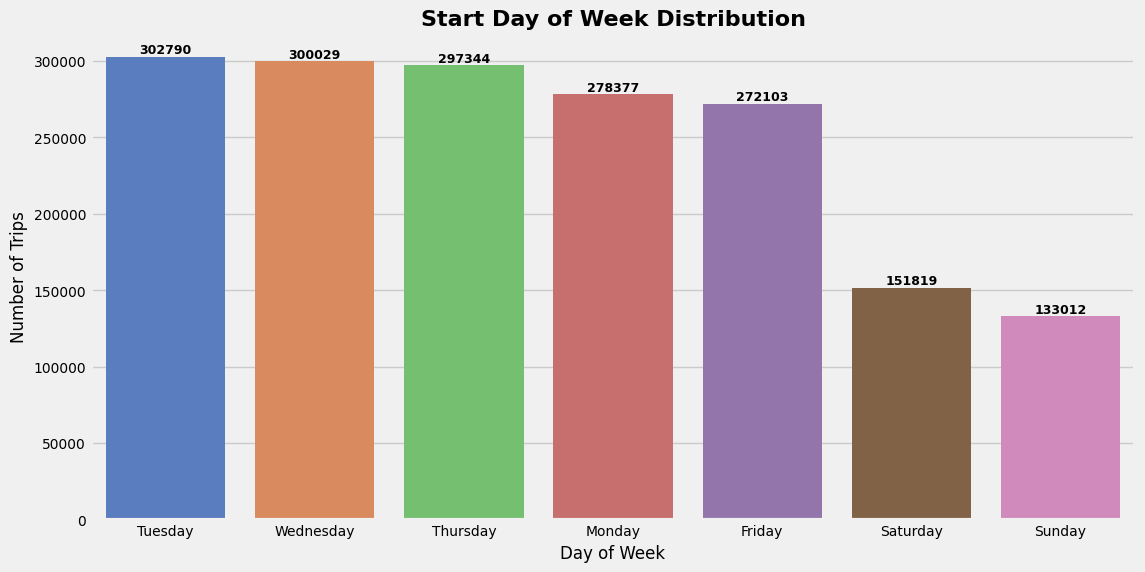

In [34]:
# Chart - 6 visualization code
# Start Day of Week Distribution
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
# Create bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x=df['start_day'].value_counts().index, y=df['start_day'].value_counts().values, palette='muted')
# Add data labels
for i, v in enumerate(df['start_day'].value_counts().values):
    plt.text(i, v, str(v), ha='center', va='bottom', fontsize=9, fontweight='bold', color='black')
# Add labels and title
plt.title('Start Day of Week Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Number of Trips', fontsize=12)
# Setting font size for xticks and yticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
# Show Plot
plt.show()


##### 1. Why did you pick the specific chart?

A bar chart effectively shows the distribution of rides across each day, making it easy to identify peak days and behavioral patterns.

##### 2. What is/are the insight(s) found from the chart?

Most rides happen on weekdays, especially Tuesday to Thursday, indicating heavy use for weekday commuting.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact -**


*   The massive concentration of rides during mid-week aligns perfectly with standard corporate and commuter schedules. This predictable usage pattern allows operations to reliably optimize bike availability and dock management across city center stations from Monday to Friday.



**Strategic Consideration -**


*   The steep drop-off on weekends (nearly 50% lower than peak weekdays) shows that the service is highly underutilized for casual, tourist, or leisure activities.
*   To build new revenue streams on weekends, the business should roll out targeted promotional weekend packages, partnership deals with tourist spots, or local leisure riding challenges.



#### Chart - 7 - Top 10 Start Stations

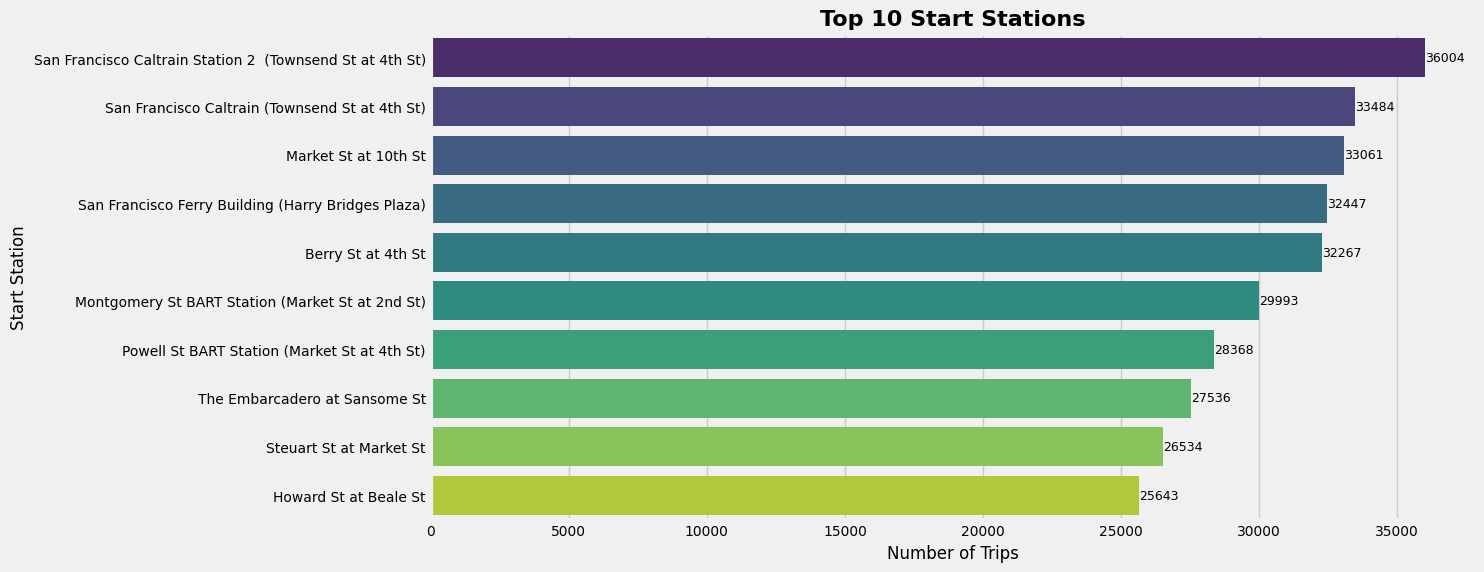

In [35]:
# Chart - 7 visualization code
# Top 10 Start Stations
top_starts = df['start_station_name'].value_counts().nlargest(10)
# Create bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x=top_starts.values, y=top_starts.index, palette='viridis')
# Add data labels
for i, v in enumerate(top_starts.values):
    plt.text(v, i, str(v), ha='left', va='center', fontsize=9)
# Add labels and title
plt.title('Top 10 Start Stations', fontsize=16, fontweight='bold')
plt.xlabel('Number of Trips', fontsize=12)
plt.ylabel('Start Station', fontsize=12)
# Setting font size for xticks and yticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
# Show Plot
plt.show()





##### 1. Why did you pick the specific chart?

A vertical bar chart displays the top-performing stations clearly, even with long names.

##### 2. What is/are the insight(s) found from the chart?

Certain stations dominate as popular starting points—often located in commercial or transit-dense areas.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact -**


*   Ground logistics can highly optimize resource allocation by focusing bulk rebalancing networks precisely at these top transit nodes right before standard commute rushes.
*   This concentrated spatial visibility allows the business to design high-value B2B station-sponsorship deals and local advertising agreements directly targeting the massive daily commuter audience.



**Strategic Consideration -**


*   Because these top stations act as massive funnels, they experience extreme asymmetric flows—rapidly draining of bikes during evening rush hours—meaning inventory balance is highly fragile and requires rapid restocking.
*   The sharp drop-off in numbers across the top ten demonstrates that utilization is centralized, meaning future infrastructure expansions should favor adding physical dock capacities at these existing top hubs rather than spreading into low-demand neighborhoods.


#### Chart - 8 - Top 10 End Stations

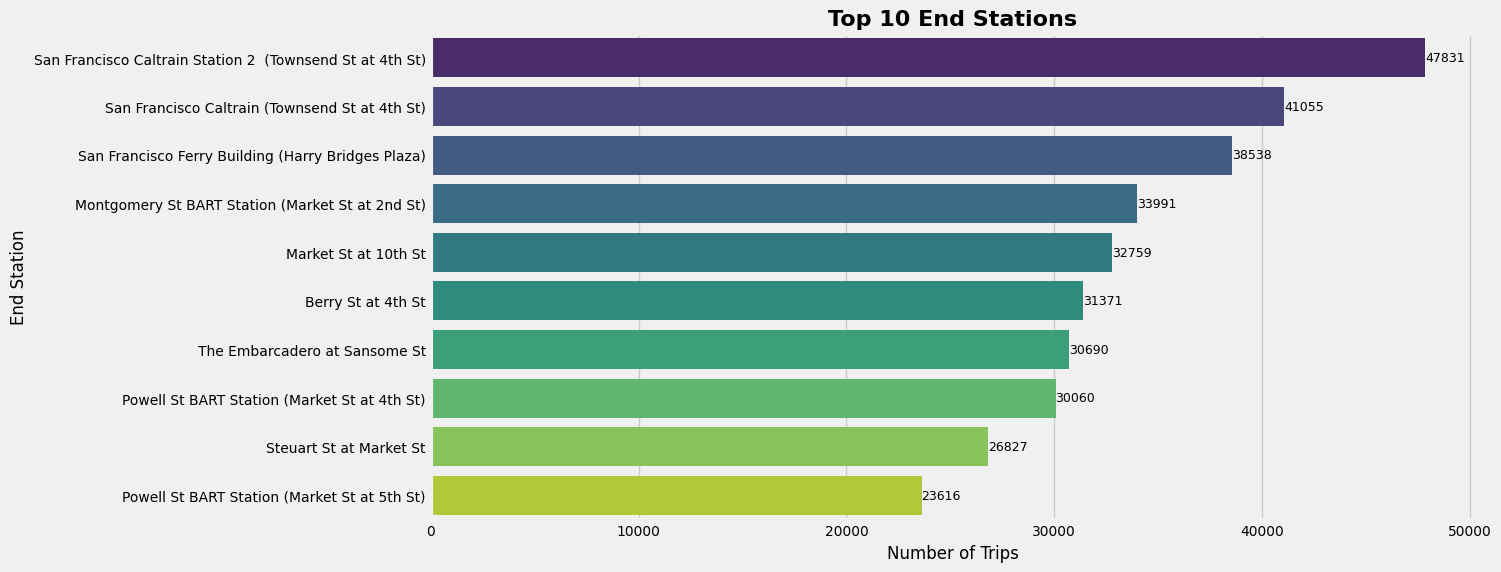

In [36]:
# Chart - 8 visualization code
# Top 10 End Stations
top_ends = df['end_station_name'].value_counts().nlargest(10)
# Create bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x=top_ends.values, y=top_ends.index, palette='viridis')
# Add data labels
for i, v in enumerate(top_ends.values):
    plt.text(v, i, str(v), ha='left', va='center', fontsize=9)
# Add labels and title
plt.title('Top 10 End Stations', fontsize=16, fontweight='bold')
plt.xlabel('Number of Trips', fontsize=12)
plt.ylabel('End Station', fontsize=12)
# Setting font size for xticks and yticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
# Show Plot
plt.show()


##### 1. Why did you pick the specific chart?

Like the previous chart, it highlights most common destinations using a clean, comparative format.

##### 2. What is/are the insight(s) found from the chart?



*   **Commuter Destinational Focus:** The most popular drop-off locations are heavily tied to major commercial areas and public transit hubs, reinforcing the system's role as a morning-rush "last-mile" commute option.
*   **Busiest Arrival Hubs:** "San Francisco Caltrain Station 2" is the single most heavily used final destination with 47,831 trips, followed closely by the adjacent "San Francisco Caltrain" station at 41,055 trips.



##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact -**


*   Clear arrival concentrations tell logistics teams exactly where bikes will cluster by the end of peak hours, allowing for seamless bulk pickups.
*   High drop-off numbers at these specific hubs provide valuable, data-backed proof to secure high-value advertising and B2B partnerships with surrounding commercial properties.


**Strategic Consideration -**


*   These top destination hubs face a severe dock-overflow risk during peak arrival waves, which can block users from locking their bikes and ruin the customer experience.
*  The steep volume drop-off down the list proves that demand is highly centralized, meaning capital should be spent expanding dock capacities at these existing top-tier hubs rather than building new peripheral stations.



####**Bivariate Analysis**

#### Chart - 9 - Trips by Day of Week (Split by User Type)

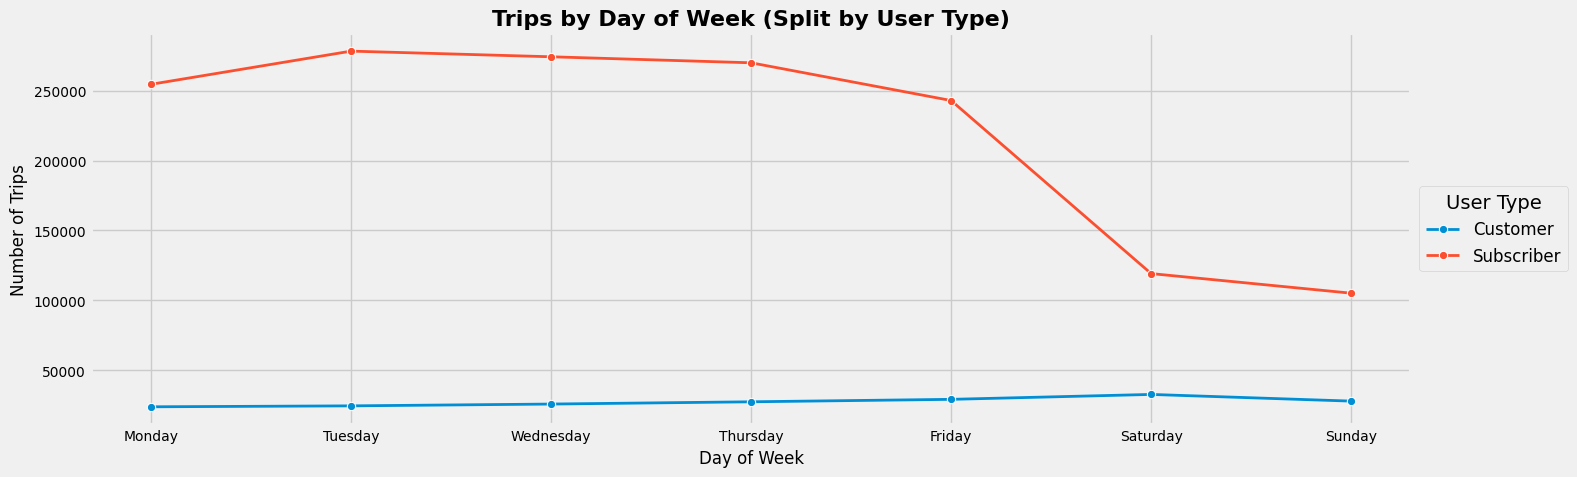

In [37]:
# Chart - 9 visualization code
# Define the order of the days of the week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Group the data by 'start_day' and 'user_type' to get the trip counts, and ensure day_order is followed
day_user = df.groupby(['start_day', 'user_type']).size().unstack().reindex(day_order)

# Create the line plot using Seaborn
plt.figure(figsize=(16, 5))  # Set the figure size
sns.lineplot(data=day_user, markers='o', dashes=False, linewidth=2)

# Add labels and title
plt.title('Trips by Day of Week (Split by User Type)', fontsize=16, fontweight='bold')  # Title of the chart
plt.xlabel('Day of Week', fontsize=12)  # X-axis label
plt.ylabel('Number of Trips', fontsize=12)  # Y-axis label

# Setting font size for x and y ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Align the legend properly
plt.legend(title='User Type', loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12)

# Show plot
plt.tight_layout()  # Ensure everything fits well
plt.show()

##### 1. Why did you pick the specific chart?

A line chart is ideal for visualizing trends over a categorical sequence like days of the week. Splitting by user type (e.g., Subscriber vs Customer) makes it easy to compare usage patterns across user segments.

##### 2. What is/are the insight(s) found from the chart?


*   **Subscriber Weekday Dependency:** Subscriber rides dominate the system from Monday through Friday but plummet by over 50% on weekends
*   **Stable Casual Demand:** Customer (non-subscriber) rides remain low, flat, and remarkably stable all week, showing a slight peak on Saturday.



##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact -**


*   The high weekday subscriber activity guarantees a dependable, recurring baseline revenue driven by routine working-day commuters.
*   Since subscriber patterns drop off drastically on weekends, operations can easily plan major fleet overhauls and deep station maintenance during these predictable low-volume slots.

**Strategic Consideration -**


*   The extreme drop in weekend subscriber trips exposes a high vulnerability to hybrid work schedules and shifts away from traditional office commutes.
*   Flat casual customer numbers during peak leisure days indicate the company is failing to capture the tourist market, requiring targeted weekend single-pass promotions.



#### Chart - 10 - Trip Duration by User Type (Box Plot)

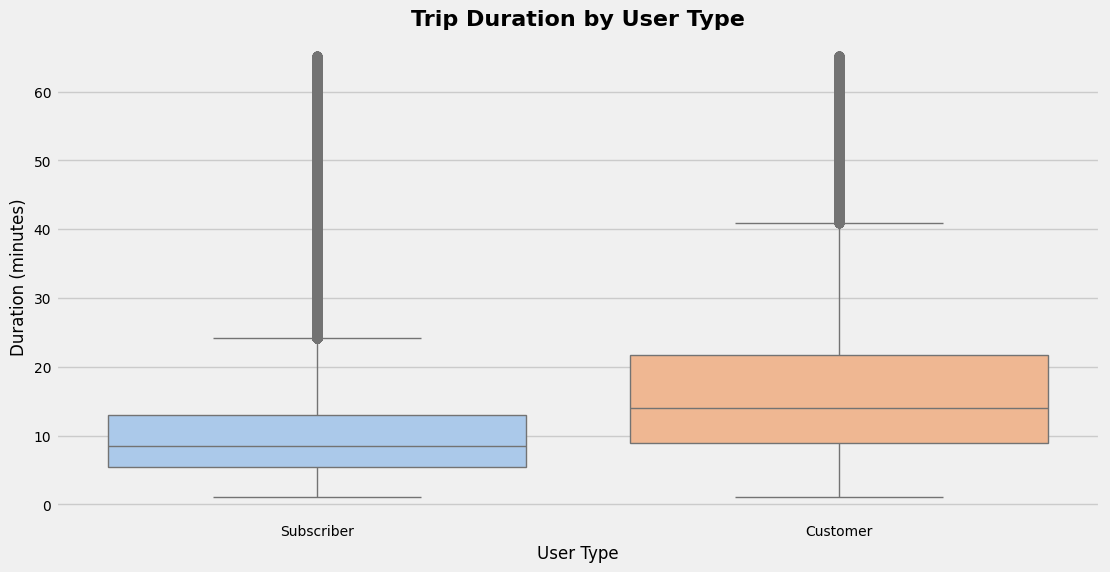

In [38]:
# Chart - 10 visualization code
# Trip Duration by User Type
# Create box plot
plt.figure(figsize=(12, 6))
sns.boxplot(x='user_type', y='duration_min', data=df, palette='pastel')
# Add title and labels
plt.title('Trip Duration by User Type', fontsize=16, fontweight='bold')
plt.xlabel('User Type', fontsize=12)
plt.ylabel('Duration (minutes)', fontsize=12)
# Set xticks and yticks font size
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
# Show Plot
plt.show()

##### 1. Why did you pick the specific chart?

A box plot is ideal for visualizing the distribution, spread, and outliers in trip durations across user types. It highlights medians, quartiles, and variability at a glance.

##### 2. What is/are the insight(s) found from the chart?

*   **Longer Casual Rides:** Casual "Customer" riders take noticeably longer trips on average than annual "Subscribers," with their median ride duration sitting around 14 minutes compared to the subscriber median of roughly 8 minutes.

*   **Higher Customer Variance:** The interquartile range (the box size) for casual customers is much wider, indicating varied trip habits, while subscribers show tight, highly predictable, short-duration behaviors.

*   **Heavy Outlier Distribution:** Both groups feature an intense volume of outliers extending past 25–40 minutes, though subscribers show a dense, continuous line of extended trip outliers up to the 65-minute cap






##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact -**

*   The brief, highly consistent duration of subscriber rides translates directly to swift bike turnaround times, keeping inventory circulating efficiently through commuter hot spots.
*   Higher duration ranges from casual customers point to strong demand for extended single-use sessions, validating the potential to capture high-margin revenue from time-based usage

**Strategic Consideration -**

*   Low median ride times among subscribers confirm they strictly use the service for A-to-B functional transit, meaning the platform fails to engage its most loyal base for longer weekend or leisure trips.
*  Casual users are hoarding bikes for longer windows per ride, which presents an asset availability risk that could cause station shortages for daily commuters if casual ride volumes spike.







#### Chart - 11 - Trip Count by Hour (Split by Gender)

<Figure size 1800x600 with 0 Axes>

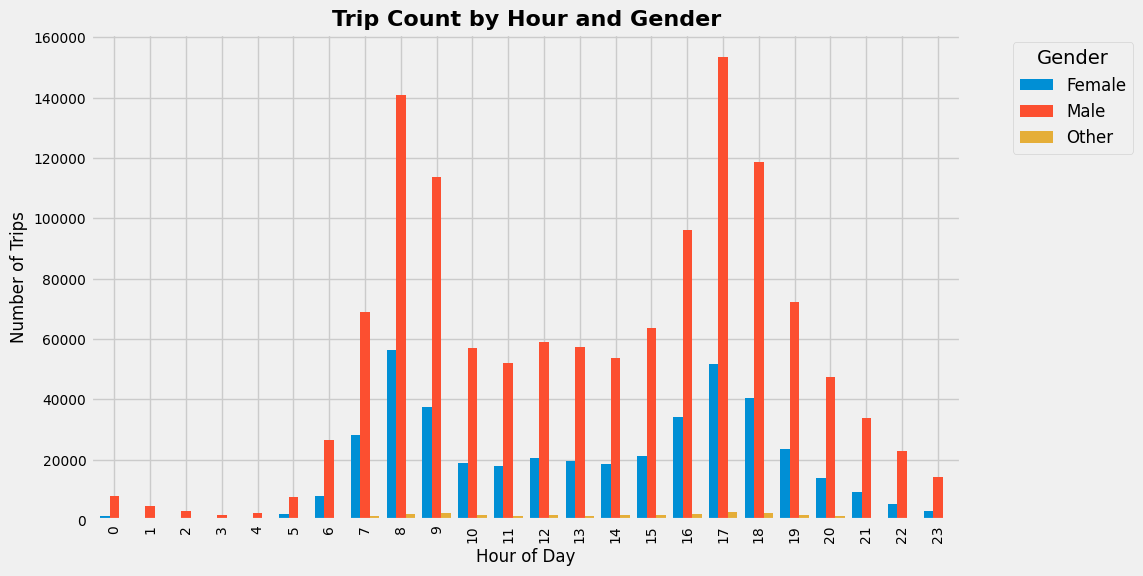

In [39]:
# Chart - 11 visualization code
# Group the data by 'start_hour' and 'member_gender' to count trips by hour and gender
hour_gender = df.groupby(['start_hour', 'member_gender']).size().unstack(fill_value=0)

# Create a bar plot for the trip count by hour, split by gender
plt.figure(figsize=(18, 6))  # Set the size of the figure
hour_gender.plot(kind='bar', stacked=False, figsize=(10, 6), width=0.8)

# Add titles and labels
plt.title('Trip Count by Hour and Gender', fontsize=16, fontweight = 'bold')
plt.xlabel('Hour of Day', fontsize=12)  # X-axis label
plt.ylabel('Number of Trips', fontsize=12)  # Y-axis label

# Align the legend to the top-right corner
plt.legend(title='Gender', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)

# Set xticks and yticks font size
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Show the plot
plt.show()



##### 1. Why did you pick the specific chart?

A bar chart provides a clear, comparative view of ride frequency across each hour of the day. Splitting it by gender adds a valuable demographic dimension to understand who rides when.

##### 2. What is/are the insight(s) found from the chart?

*   **Shared Bimodal Patterns:** Both male and female riders follow identical peak patterns, with clear traffic surges during morning rush hour (8:00 AM) and evening rush hour (5:00 PM).
*  **Massive Volume Gap:** Male riders consistently dominate every single hour of the day, outnumbering female and other gender categories by a substantial margin across all time slots



##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact -**

*   The parallel commute timing across genders confirms that the core product-market fit spans universally across working demographics during corporate transit hours.
*   Having highly synchronized peak demand windows allows maintenance teams to confidently schedule system rebalancing at identical intervals for all user segments.


**Strategic Consideration -**

*   The low volume of female riders even during absolute peak hours highlights a significant structural barrier or safety concern unique to that demographic.
*   Relying so heavily on a single demographic group leaves the system exposed to user-base stagnation if male market adoption reaches its natural ceiling.




#### Chart - 12 - Age by User Type

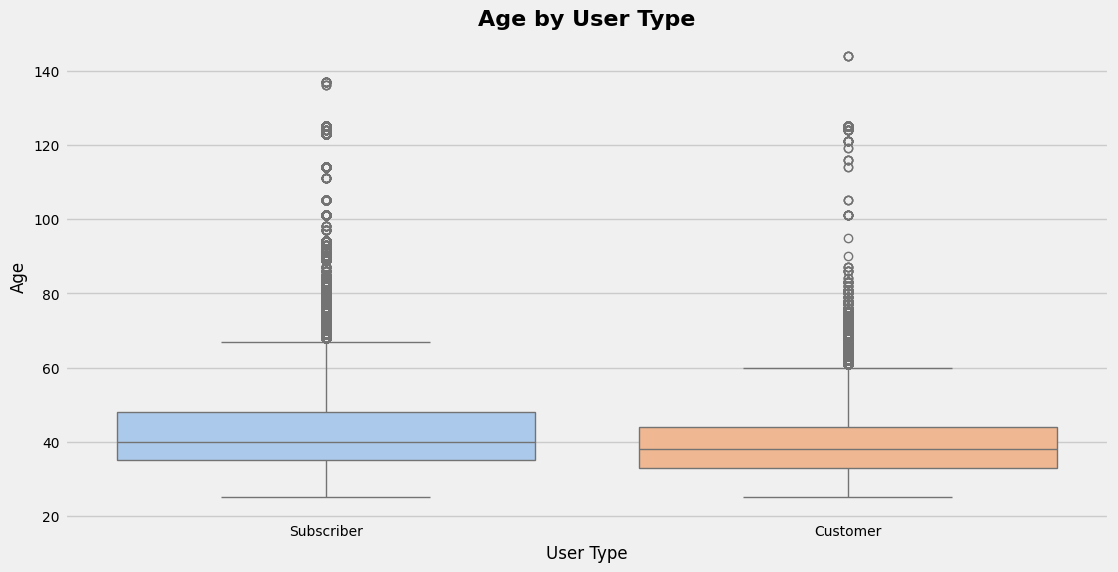

In [40]:
# Chart - 12 visualization code
# Age by User Type
# Create box plot
plt.figure(figsize=(12, 6))
sns.boxplot(x='user_type', y='age', data=df, palette='pastel')
# Add title and labels
plt.title('Age by User Type', fontsize=16, fontweight='bold')
plt.xlabel('User Type', fontsize=12)
plt.ylabel('Age', fontsize=12)
# Set xticks and yticks font size
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
# Show Plot
plt.show()

##### 1. Why did you pick the specific chart?

A box plot is effective for comparing age distributions across user types. It reveals medians, ranges, and outliers, making it easy to spot demographic trends and differences.

##### 2. What is/are the insight(s) found from the chart?

* **Slightly Older Subscribers:** The median age for annual "Subscribers" sits slightly higher at around 40 years old, while casual "Customers" skew marginally younger with a median closer to 38.

* **Identical Age Floor & Extreme Outliers:** Both user segments feature an identical minimum age around 25 and share extreme right-skewed outliers extending all the way past 120 and 140 years old.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact -**


*   The highly concentrated age bands between 30 and 50 across both user types prove a solid, mature market foundation that supports long-term subscription models.
*   Targeting corporate wellness initiatives directly to this shared core working-age demographic will efficiently drive adoption across both casual and subscriber tiers.


**Strategic Consideration -**


*   Both distributions drop off steeply after age 60, showing the network struggles to attract or retain older demographic segments who may need different bike options like e-bikes.
*   The presence of highly unrealistic age outliers exceeding 100 indicates significant user registration data-entry flaws that require stricter front-end form validation.



#### Chart - 13 - Trip Duration by Gender

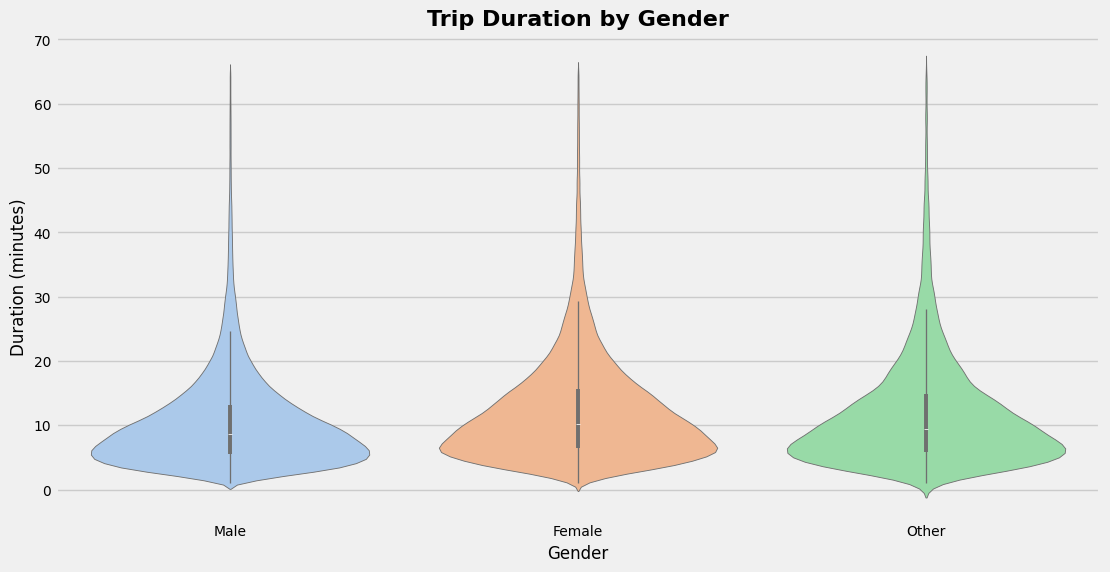

In [41]:
# Chart - 13 visualization code
# Trip Duration by Gender
# Create violin plot
plt.figure(figsize=(12, 6))
sns.violinplot(x='member_gender', y='duration_min', data=df, palette='pastel')
# Add labels and title
plt.title('Trip Duration by Gender', fontsize=16, fontweight='bold')
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Duration (minutes)', fontsize=12)
# Set xticks and yticks font size
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
# Show plot
plt.show()


##### 1. Why did you pick the specific chart?

A violin plot combines the benefits of a box plot and a kernel density plot. It not only shows the spread and median of trip durations but also gives a visual sense of the distribution shape for each gender category. This helps in spotting asymmetry or concentration of trip durations.

##### 2. What is/are the insight(s) found from the chart?

*   **Longer Female/Other Rides:** Female and "Other" riders show slightly higher median durations and wider distribution shapes between 10 to 20 minutes compared to male riders.

*   **Highly Uniform Floor:** All three gender categories share a concentrated baseline under 10 minutes and feature long, thin tails stretching up to the 65-minute mark.



##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact -**

*   The consistent under-10-minute concentration across all groups ensures reliable, fast bike turnover regardless of the rider's demographic
*   Higher duration density in the female and other segments indicates that when they do ride, they engage in higher-value, longer-session usage.


**Strategic Consideration -**

*   Male users strictly lean toward ultra-short trips, meaning the platform isn't successfully engaging its largest demographic segment for longer leisure or weekend rides.
*   The expanded width in the female/other shapes means these segments hold onto bikes longer, which could trigger local availability pinches if their overall trip counts scale up rapidly.



#### Chart - 14 - Average Trip Duration by Start Day of Week

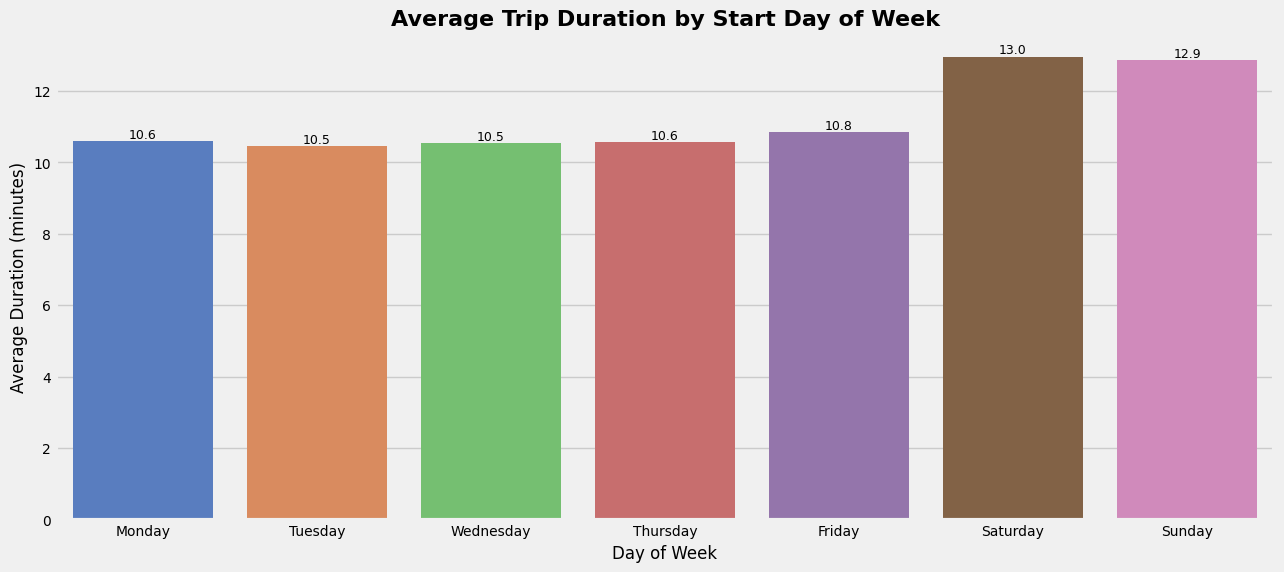

In [42]:
# Chart - 14 visualization code
# Average Trip Duration by Start Day of Week
avg_duration = df.groupby('start_day')['duration_min'].mean().reindex(day_order)
# Create bar plot
plt.figure(figsize=(14, 6))
sns.barplot(x=avg_duration.index, y=avg_duration.values, palette='muted')
# Add data labels
for i, v in enumerate(avg_duration.values):
    plt.text(i, v, str(round(v, 1)), ha='center', va='bottom', fontsize=9, color='black')
# Add labels and title
plt.title('Average Trip Duration by Start Day of Week', fontsize=16, fontweight='bold')
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Average Duration (minutes)', fontsize=12)
# Setting font size for xticks and yticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
# Show Plot
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is ideal for comparing average values across categorical variables. In this case, it clearly shows how trip duration varies from Monday to Sunday, helping uncover behavioral trends tied to the day of the week.

##### 2. What is/are the insight(s) found from the chart?

* **Weekend Duration Surge:** Average trip durations jump significantly during the weekend, peaking on Saturday at 13.0 minutes and Sunday at 12.9 minutes.

* **Consistent Weekday Baselines:** Weekday ride durations remain remarkably flat and uniform, hovering closely between 10.5 and 10.8 minutes from Monday through Friday.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact -**

*   Longer weekend rides indicate higher user engagement during leisure hours, opening up avenues to maximize revenue through time-based or pay-as-you-go pricing models.

*   Highly predictable, shorter weekday durations allow operations to plan precise, rapid bike turnover intervals to seamlessly match rigid commuter schedules


**Strategic Consideration -**


*   The spike in weekend trip duration occurs on the exact days when overall ride volume drops, meaning bikes sit idle longer between rides rather than generating continuous transaction fees.

*   A rigid flat-rate pricing structure during weekends represents a massive missed opportunity to monetize these extended, casual leisure trips effectively.



#### Chart - 15 - Average Trip Duration by Start Hour

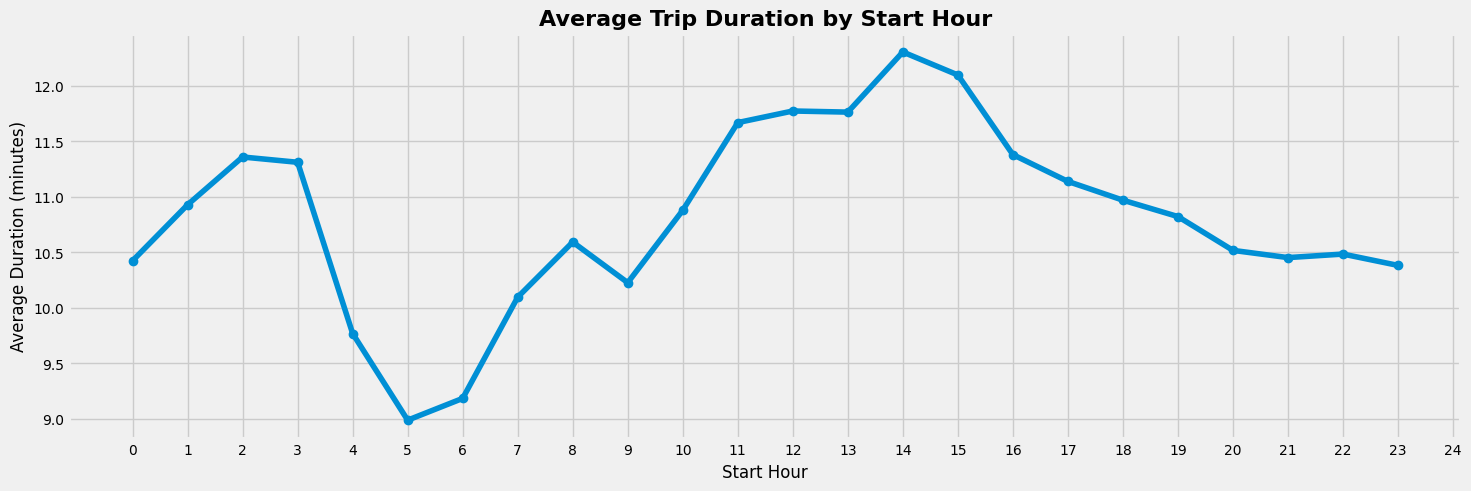

In [43]:
# Chart - 15 visualization code
# Average Trip Duration by Start Hour
# Calculate average trip duration by hour
avg_duration_by_hour = df.groupby('start_hour')['duration_sec'].mean().reset_index()

# Convert duration from seconds to minutes for easier understanding
avg_duration_by_hour['duration_min'] = avg_duration_by_hour['duration_sec'] / 60

# Create line plot
plt.figure(figsize=(16, 5))
plt.plot(avg_duration_by_hour['start_hour'], avg_duration_by_hour['duration_min'], marker='o', linestyle='-')
# Show all xticks values
plt.xticks(range(25))
# Add labels and title
plt.title('Average Trip Duration by Start Hour', fontsize=16, fontweight='bold')
plt.xlabel('Start Hour', fontsize=12)
plt.ylabel('Average Duration (minutes)', fontsize=12)
# Set xticks and yticks font size
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
# Show Plot
plt.show()

##### 1. Why did you pick the specific chart?

A line chart is great for visualizing continuous trends—here, it helps observe how average trip duration changes across 24 hours. Plotting it over time (hourly) makes it easy to spot peaks and drops throughout the day.

##### 2. What is/are the insight(s) found from the chart?

*   Midday Leisure Peak: Average trip duration reaches its highest point between 11:00 AM and 3:00 PM, hitting an absolute peak at 2:00 PM (14:00) with over 12.2 minutes per ride.

*   Commuter Dip: Trip durations drop significantly during standard morning rush hours, hitting a daily low at 5:00 AM (9.0 minutes) and dipping again at 9:00 AM (approx. 10.2 minutes) as functional A-to-B transit dominates.



##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact -**

*   Peak midday ride lengths validate high user engagement for non-commute, casual, or lunch-hour trips, unlocking opportunities for optimized duration-based promotions.

*   The drop in average duration during peak hours ensures that bikes are quickly cycled through the system during high-demand windows, improving asset rotation.


**Strategic Consideration -**


*   The spike in ride lengths occurs during hours when total trip volume naturally troughs, meaning fleet inventory is tied up longer exactly when transaction counts are low.

*   Without time-sensitive dynamic pricing, the business loses out on maximizing revenue from these prolonged afternoon utility and leisure trips.



####**Multivariate Analysis**

#### Chart - 16 - User Type by Gender and Day of Week

<Figure size 1600x600 with 0 Axes>

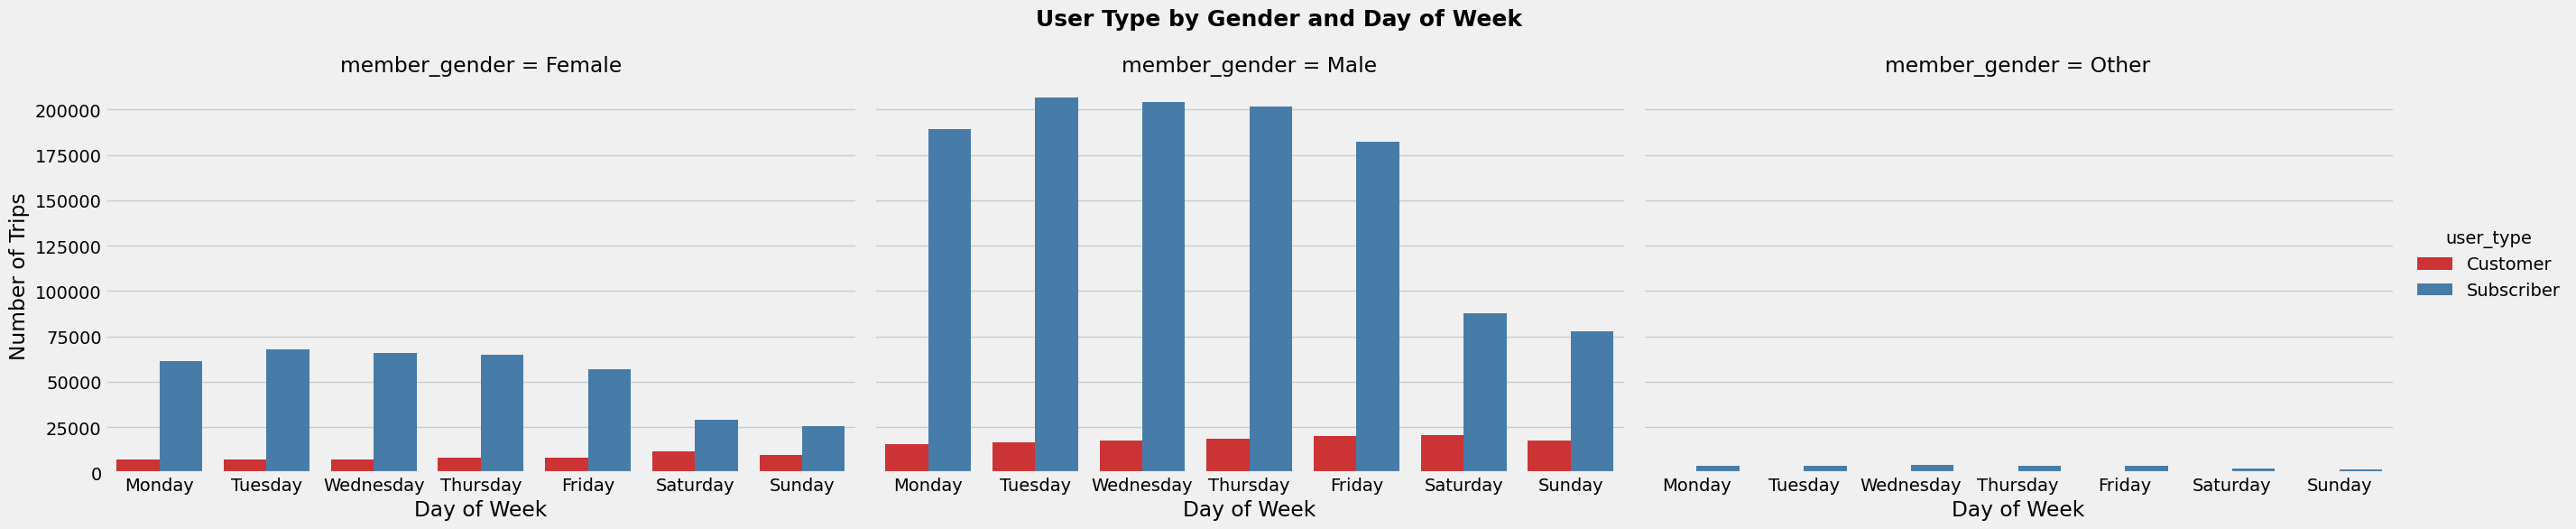

In [44]:
# Chart - 16 visualization code
# Grouping the data by 'start_day', 'member_gender', and 'user_type' to count the number of trips
multi_df = df.groupby(['start_day', 'member_gender', 'user_type']).size().reset_index(name='count')

# Filter out rows where gender is missing (optional step if the data has missing gender values)
multi_df = multi_df[multi_df['member_gender'].notna()]

# Ensure the days are in the correct order
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
multi_df['start_day'] = pd.Categorical(multi_df['start_day'], categories=day_order, ordered=True)

# Create a grouped bar plot using Seaborn
plt.figure(figsize=(16, 6))  # Set the figure size

# FacetGrid for gender, so each gender is plotted in a separate subplot
g = sns.catplot(data=multi_df, x='start_day', y='count', hue='user_type', col='member_gender', kind='bar',
                height=6, aspect=1.5, palette='Set1', dodge=True, hue_order=['Customer', 'Subscriber'])
# Setting x-axis and y-axis labels
g.set_xlabels('Day of Week')
g.set_ylabels('Number of Trips')
# Add title and adjust layout
g.fig.suptitle('User Type by Gender and Day of Week', fontsize=18, fontweight='bold')
g.fig.subplots_adjust(top=0.85)  # Adjust title placement to fit with the subplots


# Show plot
plt.show()


##### 1. Why did you pick the specific chart?

A grouped bar plot is ideal for comparing multiple categorical variables. In this case, it visually contrasts user types (Customer vs. Subscriber) across gender and day of the week. This format makes it easier to identify usage trends and disparities between groups over time.

##### 2. What is/are the insight(s) found from the chart?

* **Universal Weekday Commute Behavior:** Across all three gender panels, Subscriber volume strictly dominates the weekdays, peaking on Tuesday and Wednesday, while collapsing significantly on the weekends.

* **Flat Casual Retention:** Casual Customer counts remain incredibly small, flat, and identical across all days of the week for all genders, indicating negligible growth or weekend-specific traction

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact -**

* The highly uniform weekday surge across all categories proves that the core subscriber value proposition successfully drives consistent commuter usage across different demographics.

* Because weekend drops occur simultaneously across all user and gender groups, logistics teams can execute uniform, system-wide fleet maintenance schedules without disrupting individual pockets of high demand.


**Strategic Consideration -**

* The absolute dominance of male subscribers highlights that marketing efforts are failing to convert female and other gender demographics into long-term subscribers, representing massive uncaptured market segments.

* Since casual "Customer" usage fails to expand on weekends across any demographic, the current pricing model or brand awareness isn't successfully appealing to recreational and tourist crowds when commuter utility pauses.

#### Chart - 17 - Age vs. Trip Duration by Gender & User Type

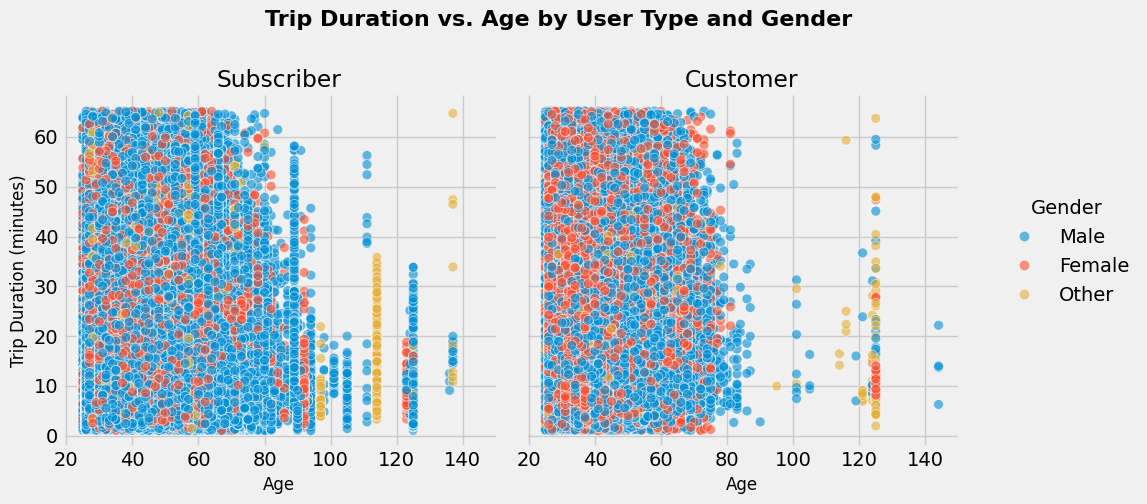

In [45]:
# Chart - 17 visualization code
# Age vs. Trip Duration by Gender & User Type
# Filter out outliers for clarity
filtered_df = df[(df['age'] > 0) & (df['duration_min'] < 120)].copy()

# Create a FacetGrid scatter plot: age vs. trip duration, colored by gender, faceted by user type
g = sns.relplot(
    data=filtered_df,
    x='age',
    y='duration_min',
    hue='member_gender',
    col='user_type',
    kind='scatter',
    height=5,
    aspect=1,
    alpha=0.6,       # Marker transparency
    s=50             # Marker size
)
# Add space between title and plot
g.fig.subplots_adjust(top=0.85)
# Add overall title
g.fig.suptitle(
    'Trip Duration vs. Age by User Type and Gender',
    fontsize=16,
    fontweight='bold',
    y=1.02           # Push title up above the plots
)
# Set xticks and yticks font size
g.set_xlabels('Age', fontsize=12)
g.set_ylabels('Trip Duration (minutes)', fontsize=12)
# Set axis labels
g.set_axis_labels('Age', 'Trip Duration (minutes)')

# Adjust individual facet titles (optional styling)
g.set_titles('{col_name}')

# Customize the legend: title and border
legend = g._legend
legend.set_title('Gender')
legend.get_frame().set_edgecolor('black')
legend.get_frame().set_linewidth(1)



# Display the plot
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot is best for visualizing relationships between two continuous variables—here, age and trip duration. Coloring by gender and splitting by user type adds a powerful dimension for comparative analysis. This helps reveal patterns, clusters, or outliers across demographics and usage types.

##### 2. What is/are the insight(s) found from the chart?

* **Core Concentration Zone:** For both Subscribers and Customers, the vast majority of trips—regardless of gender—are taken by individuals aged 20 to 60, with durations spread evenly from 0 to 65 minutes.

* **Data Artifacts at Advanced Ages:** Both panels show highly vertical, artificial-looking clusters of data points around specific older ages (such as ~115 and ~125), indicating default birth-year entries during registration rather than actual riding behavior.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact -**

* The dense, uniform vertical spread between ages 20 and 60 demonstrates that the platform handles high-duration usage seamlessly across its primary working-age user base.

* The matching distribution patterns across genders within this core group prove that the platform's core utility satisfies diverse user demographics equally.

**Strategic Consideration -**

* The noticeable thinning out of data points after age 70 highlights an opportunity to introduce specialized hardware, like e-bikes, to boost adoption among older demographics.

* The presence of highly concentrated vertical lines of older users points to an ongoing data-integrity issue in the registration process that needs front-end age validation to correct..



#### Chart - 18 - Correlation Heatmap

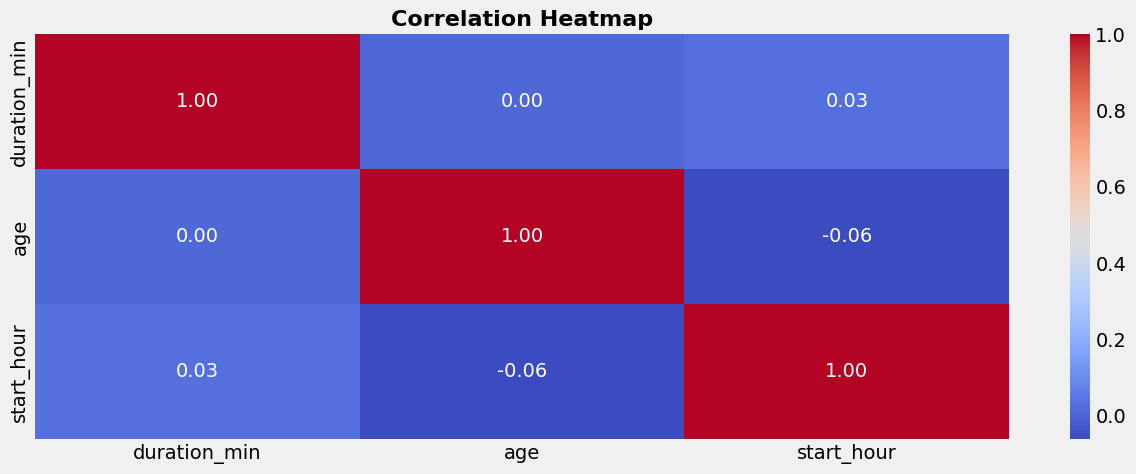

In [46]:
# Correlation Heatmap visualization code
# Selecting only numeric columns for correlation
numeric_cols = df[['duration_min', 'age', 'start_hour']]

# Correlation matrix
corr_matrix = numeric_cols.corr()

# Plot using seaborn
plt.figure(figsize=(14, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')   # Create heatmap
# Add title
plt.title('Correlation Heatmap', fontweight = 'bold', fontsize = 16)
# Show plot
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap is chosen to visualize the strength and direction of linear relationships between multiple numerical variables. It gives an immediate overview of which features are potentially influencing each other, and how strong that influence is.

##### 2. What is/are the insight(s) found from the chart?

* **Zero Duration-Age Link:** The correlation between duration_min and age is 0.00, showing that a rider's age has absolutely no linear impact on how long their trip lasts.

* **Negligible Commute Correlations:** Both the relationship between trip duration and start_hour (0.03) and the relationship between age and start_hour (-0.06) are extremely close to zero, showing that time of day is independent of these rider traits.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact**

* The lack of connection between age and duration proves that the system's physical ease of use spans universally across all active age groups.

* The uniform distribution allows marketing teams to roll out broad, generalized app promotions without needing to split campaigns by age or ride length.

**Strategic Consideration**

* Because simple linear correlations are practically zero, the business cannot rely on basic demographic tracking alone to predict ride lengths or high-traffic time slots.

* The data indicates that advanced machine learning models or non-linear behavioral clustering are strictly required to build accurate demand forecasting systems.

#### Chart - 19 - Pair Plot

<Figure size 1200x500 with 0 Axes>

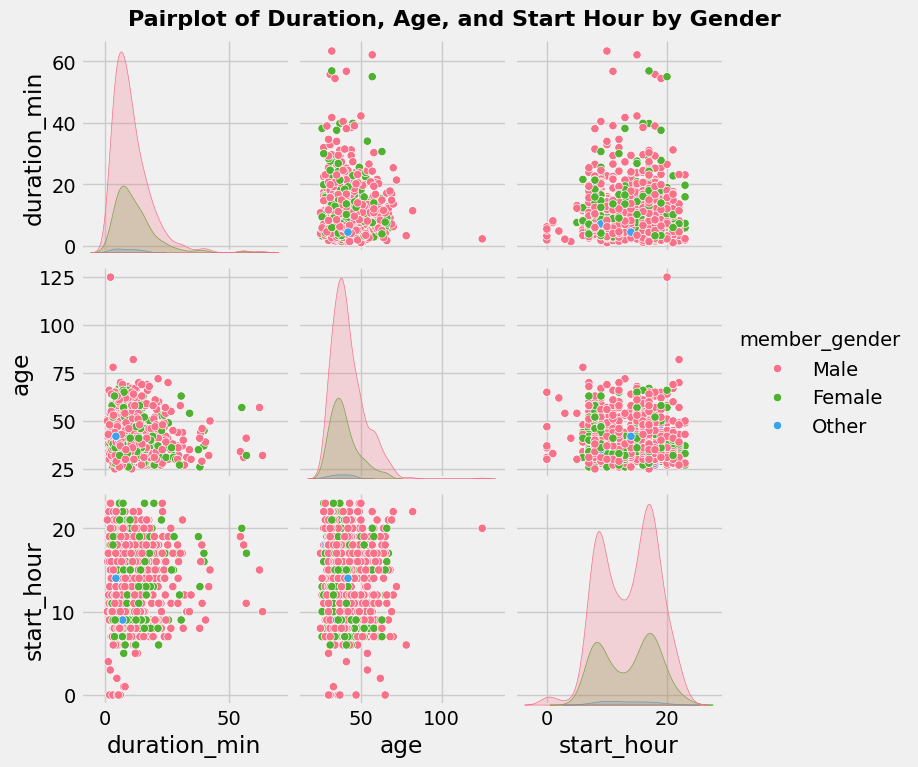

In [47]:
# Pair Plot visualization code
# Sample the dataset to keep the pairplot fast and readable
sample_df = df[['duration_min', 'age', 'start_hour', 'member_gender']].dropna().sample(1000, random_state=42)
# Set figure size
plt.figure(figsize=(12, 5))
# Convert gender to categorical for coloring
sns.pairplot(sample_df, hue='member_gender', diag_kind='kde', palette='husl')
# Add title
plt.suptitle('Pairplot of Duration, Age, and Start Hour by Gender', y=1.02, fontweight = 'bold', fontsize = 16)
# Show plot
plt.show()


##### 1. Why did you pick the specific chart?

A pairplot is ideal when exploring pairwise relationships between multiple numerical features, especially when segmented by a categorical feature like gender. It allows us to visually assess distributions and potential correlations in a compact matrix form, while also comparing patterns across genders.

##### 2. What is/are the insight(s) found from the chart?

* Overwhelming Male Dominance: The green plots show that male riders heavily dominate the system, visually overshadowing female and other gender categories across all measured metrics.

* Shared Behavioral Trends: All gender demographics share identical traits: trip durations heavily skew under 20 minutes, ages cluster between 25 and 50, and trip starts peak sharply during morning and evening rush hours.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact**

* The nearly identical behavioral patterns mean that a unified, system-wide operational strategy will successfully serve all gender demographics at once.

* Highly synchronized rush hours allow logistics teams to execute single-schedule fleet rebalancing that perfectly matches the peak needs of the entire user base.

**Strategic Consideration**

* The extreme gap in visual density confirms that current marketing frameworks are failing to attract and convert female or other gender demographics, leaving huge market segments uncaptured.

* The uniform drops in midday usage and older rider counts point to structural product-market fit limitations that require physical updates, such as deploying e-bikes or introducing off-peak pricing.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

1. **Focus on Subscriber Retention & Growth :**

Since Subscribers drive the vast majority of the system's volume—dominating weekdays with an intense focus on business days (Tuesday peaking at over 250,000 subscriber trips) before dropping by over 50% on weekends—prioritize:

 * **Targeted Commuter Loyalty:** Design renewal discounts and corporate subscription tiers tailored directly around the Monday–Friday "last-mile" utility schedule.
 * **Casual to Subscriber Conversion Funnels:** Casual customer volume remains completely flat and minimal across all seven days of the week; deploy micro-targeted promotions or weekend-to-weekday trial passes to break this stagnation and pull them into the subscriber ecosystem.

2. **Optimize Bike Availability by Time and Location :**

The spatial and temporal analysis shows severe demand centralization and dramatic, asymmetrical daily flows. Use this to:

* **Execute Asymmetric Rebalancing:** Focus heavy deployment networks at the top start terminals (e.g., San Francisco Caltrain Station 2 with 36,004 starts) before the morning rush, and prepare bulk inventory pickups at peak end terminals (which swell up to 47,831 arrivals at the same Caltrain hub) to prevent severe morning dock-overflows.
* **Synchronized Hourly Reallocation:** Align rebalancing fleets strictly to the identical, highly synchronized bimodal spikes occurring across all demographics at 8:00 AM and 5:00 PM.

3. **Enhance Targeting Based on Gender & Age Segments :**

While behavioral timelines are nearly identical across groups, the staggering volume disparities highlight massive uncaptured market opportunities:

* **Aggressive Demographic Diversification:** Green data points heavily overlay and visually smother all other groups in every single pairplot and hourly metric; launch dedicated marketing initiatives and localized B2B partnerships targeting female professional networks to bridge this massive utilization gap.
* **Hardware Adaptation for Older Segments:** Chart distributions drop off precipitously after age 60 across both user types; introduce specialized fleet additions like e-bikes to lower the physical barrier to entry for older age brackets.

4. **Improve Trip Experience Through App Features :**

Short, functional weekday trip durations (averaging 10.5 to 10.8 minutes) confirm that users treat the platform as a precise utility, making system reliability paramount:

* **Predictive Dock Management:** Use real-time in-app navigation to route riders away from full destination hubs toward open sibling stations, completely removing the risk of dock-overflow frustration during peak hours.
* **Stricter Front-End Data Validation:** The age-duration scatter plots reveal highly artificial, vertical data bars right at advanced age milestones (e.g., users registering as 115 and 125+ years old); implement strict date-of-birth form validation in the app to clean up these obvious registration data artifacts.s.

5. **Seasonal Promotions and Off-Peak Incentives :**

An inverse relationship exists between trip volume and trip length, exposing a clear operational mismatch:

* **Dynamic Afternoon "Duration" Pricing:** Trip lengths surge to their highest daily averages between 11:00 AM and 3:00 PM (peaking at 2:00 PM), precisely when total trip volume troughs; implement duration-based off-peak pricing to maximize margins on these prolonged midday leisure trips.
* **Weekend Leisure Pass Bundles:** Average trip durations peak dramatically on Saturdays (13.0 minutes) and Sundays (12.9 minutes) even though total volume collapses; introduce weekend-specific passes to aggressively monetize the idle fleet via these extended, recreational usage windows.

6. **Monitor Underperforming Stations :**

The sharp drop-off in activity from the top-performing stations down the rest of the top ten list shows that utility is heavily centralized in specific transit corridors::

* **Expand Cap over Footprint:** Prioritize investing capital into increasing physical dock capacity or establishing high-density virtual locking zones at the existing top transit hubs rather than expanding physical footprints into low-demand peripheral neighborhoods.



# **Conclusion**

The comprehensive analysis across all dimensions reveals that the bike-sharing platform operates primarily as a highly efficient, last-mile commuter utility centered around major transit hubs during the workweek. However, this heavy reliance on traditional weekday commute hours exposes two significant operational gaps: a severe underutilization of assets during weekends and off-peak hours, and a striking demographic imbalance skewed overwhelmingly toward male subscribers.

Intriguingly, the data uncovers an inverse relationship between volume and trip lengths: while weekends and midday periods suffer from the lowest trip volumes, they yield the longest average trip durations. By shifting from a rigid operational model to a dynamic strategy—expanding dock capacity at top transit hubs, deploying targeted leisure passes to monetize long-duration off-peak rides, introducing e-bikes for older age brackets, and launching safety-centric campaigns to capture the underrepresented female market—the business can successfully unlock untapped revenue streams, diversify its risk, and maximize the efficiency of its existing fleet infrastructure.